In [1]:


"https://colab.research.google.com/drive/1cX878kWVeTCIhkNmqYPwa_epkA3kB1Uw"


!pip install requests pandas

import requests
import pandas as pd
import time

API_KEY = "21d26b4a54e7128929ed2bb80e3e036b"


BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

states = {
    "Andhra Pradesh": "Amaravati",
    "Arunachal Pradesh": "Itanagar",
    "Assam": "Dispur",
    "Bihar": "Patna",
    "Chhattisgarh": "Raipur",
    "Goa": "Panaji",
    "Gujarat": "Gandhinagar",
    "Haryana": "Chandigarh",
    "Himachal Pradesh": "Shimla",
    "Jharkhand": "Ranchi",
    "Karnataka": "Bengaluru",
    "Kerala": "Thiruvananthapuram",
    "Madhya Pradesh": "Bhopal",
    "Maharashtra": "Mumbai",
    "Manipur": "Imphal",
    "Meghalaya": "Shillong",
    "Mizoram": "Aizawl",
    "Nagaland": "Kohima",
    "Odisha": "Bhubaneswar",
    "Punjab": "Chandigarh",
    "Rajasthan": "Jaipur",
    "Sikkim": "Gangtok",
    "Tamil Nadu": "Chennai",
    "Telangana": "Hyderabad",
    "Tripura": "Agartala",
    "Uttar Pradesh": "Lucknow",
    "Uttarakhand": "Dehradun",
    "West Bengal": "Kolkata"
}

weather_list = []



for state, city in states.items():

    # API URL
    url = f"{BASE_URL}?q={city}&appid={API_KEY}&units=metric"

    print("\nAPI URL :")
    print(url)

    # GET REQUEST
    response = requests.get(url)

    # STATUS CODE
    print("Status Code :", response.status_code)

    # SUCCESS
    if response.status_code == 200:

        data = response.json()

        weather_data = {
            "State": state,
            "Capital": city,
            "Temperature": data["main"]["temp"],
            "Feels_Like": data["main"]["feels_like"],
            "Humidity": data["main"]["humidity"],
            "Pressure": data["main"]["pressure"],
            "Weather": data["weather"][0]["description"],
            "Wind_Speed": data["wind"]["speed"],
            "Clouds": data["clouds"]["all"],
            "Visibility": data.get("visibility", "N/A")
        }

        weather_list.append(weather_data)

        print("Data Fetched Successfully")

    else:

        print("API Error")
        print(response.json())

    # Delay
    time.sleep(1)

df = pd.DataFrame(weather_list)


df.to_csv("india_weather_data.csv", index=False)



print("\nComplete Weather Data")
print(df)

print("\nCSV File Saved Successfully")


API URL :
https://api.openweathermap.org/data/2.5/weather?q=Amaravati&appid=21d26b4a54e7128929ed2bb80e3e036b&units=metric
Status Code : 200
Data Fetched Successfully

API URL :
https://api.openweathermap.org/data/2.5/weather?q=Itanagar&appid=21d26b4a54e7128929ed2bb80e3e036b&units=metric
Status Code : 200
Data Fetched Successfully

API URL :
https://api.openweathermap.org/data/2.5/weather?q=Dispur&appid=21d26b4a54e7128929ed2bb80e3e036b&units=metric
Status Code : 200
Data Fetched Successfully

API URL :
https://api.openweathermap.org/data/2.5/weather?q=Patna&appid=21d26b4a54e7128929ed2bb80e3e036b&units=metric
Status Code : 200
Data Fetched Successfully

API URL :
https://api.openweathermap.org/data/2.5/weather?q=Raipur&appid=21d26b4a54e7128929ed2bb80e3e036b&units=metric
Status Code : 200
Data Fetched Successfully

API URL :
https://api.openweathermap.org/data/2.5/weather?q=Panaji&appid=21d26b4a54e7128929ed2bb80e3e036b&units=metric
Status Code : 200
Data Fetched Successfully

API URL :
h

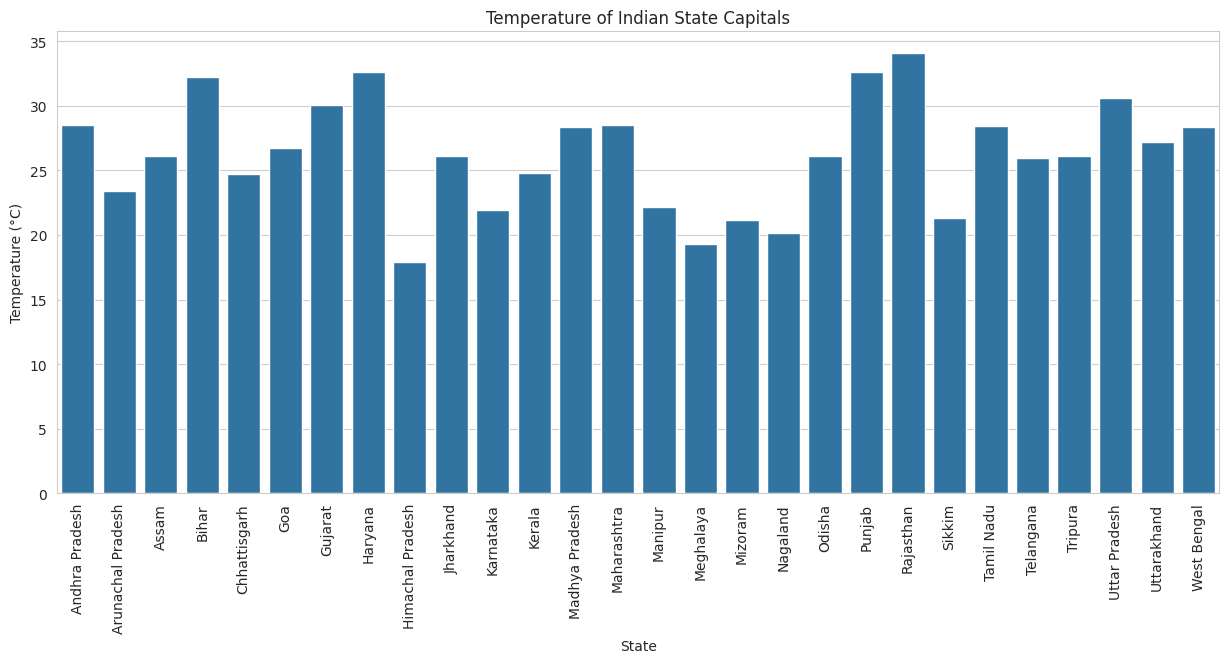

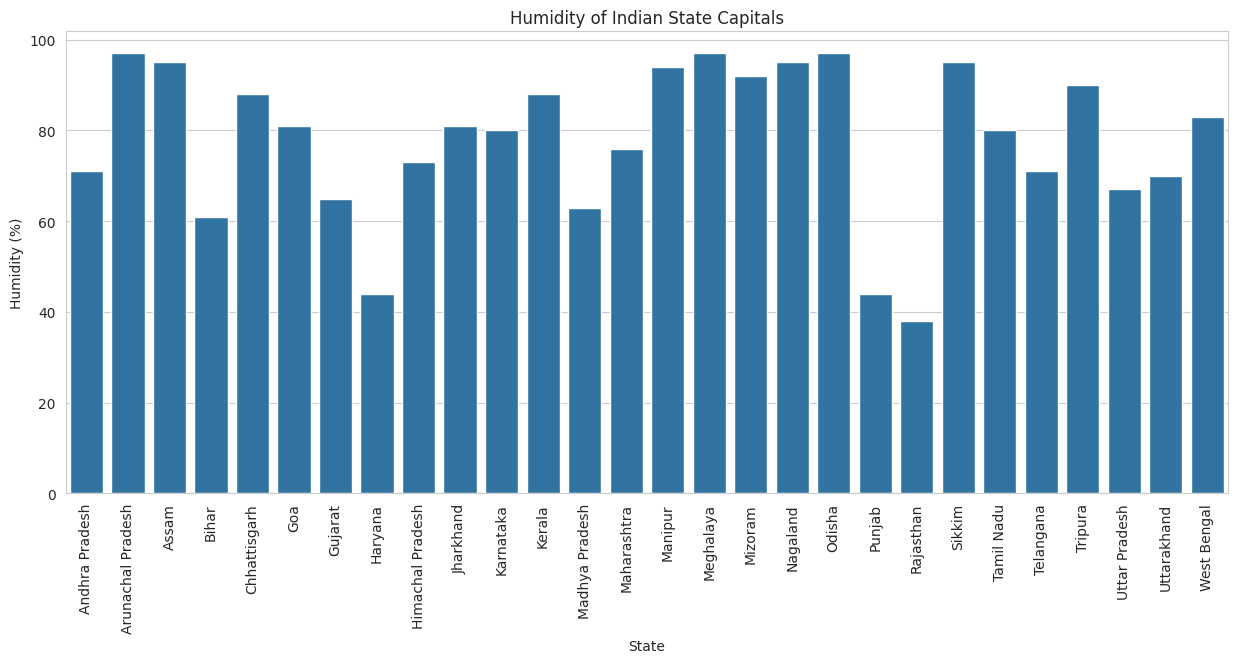

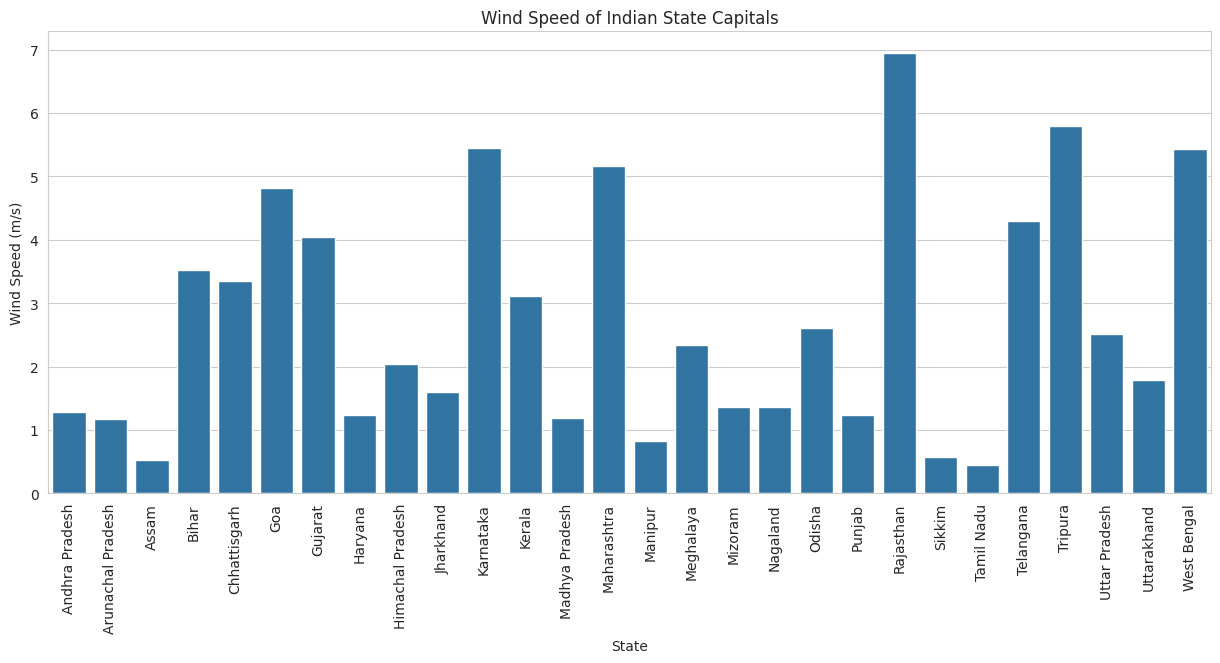

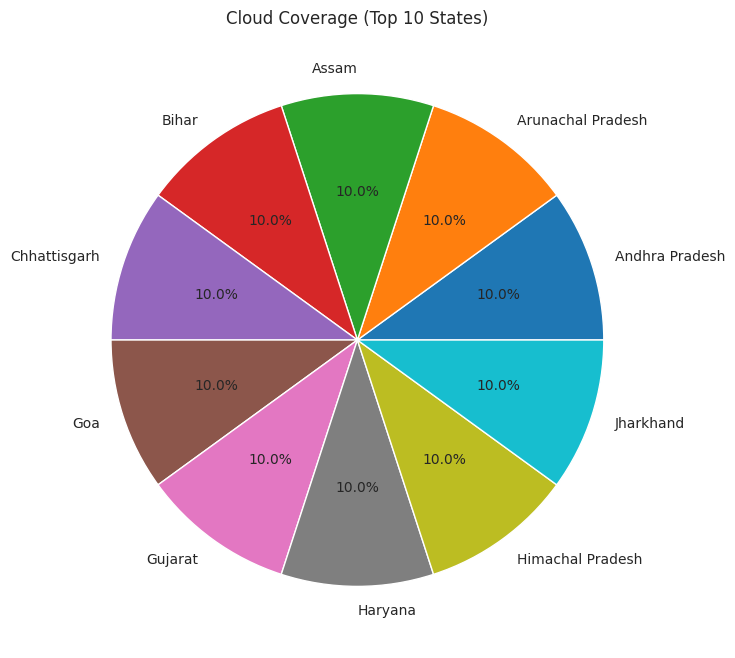

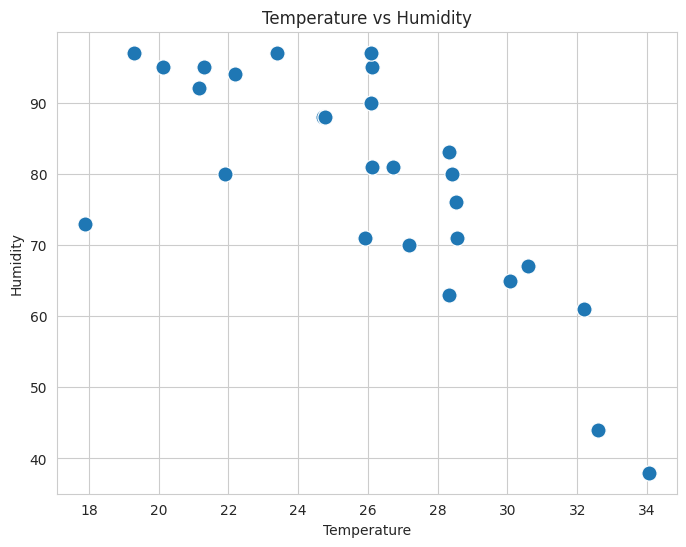

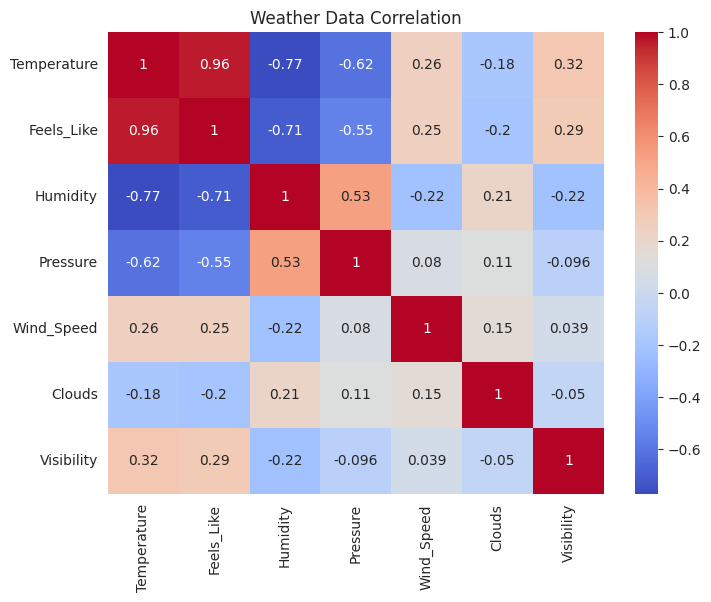

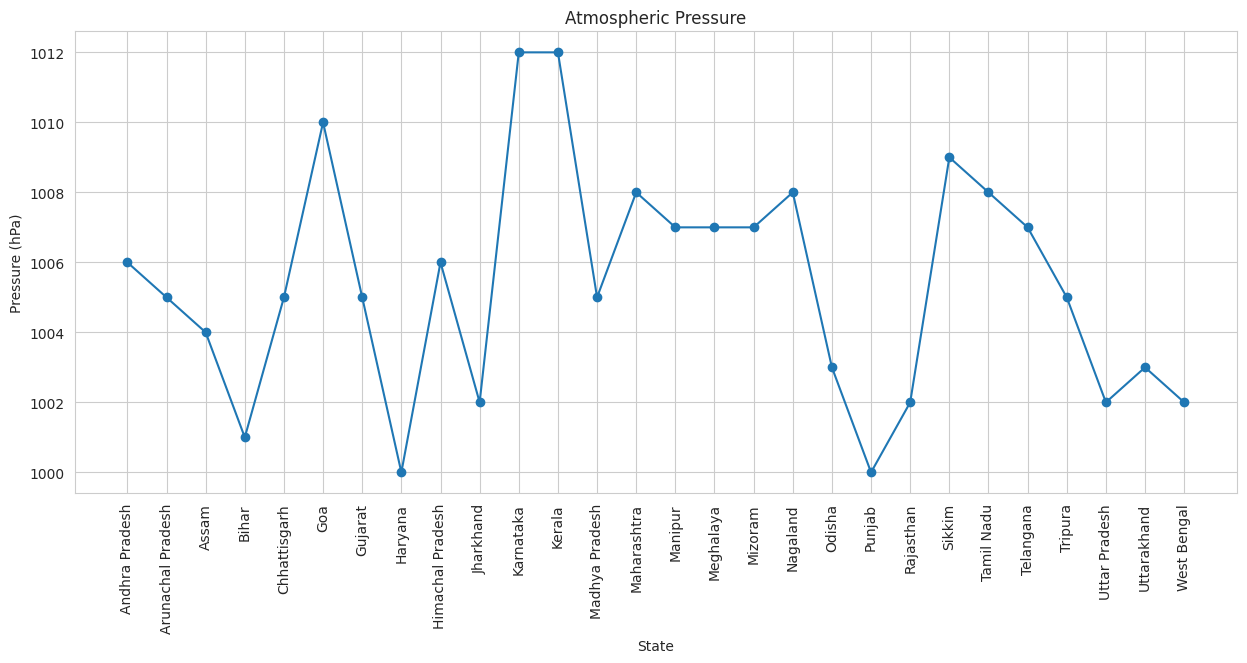

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(15,6))

sns.barplot(x="State", y="Temperature", data=df)

plt.xticks(rotation=90)
plt.title("Temperature of Indian State Capitals")
plt.xlabel("State")
plt.ylabel("Temperature (°C)")

plt.show()
plt.figure(figsize=(15,6))

sns.barplot(x="State", y="Humidity", data=df)

plt.xticks(rotation=90)
plt.title("Humidity of Indian State Capitals")
plt.xlabel("State")
plt.ylabel("Humidity (%)")

plt.show()
plt.figure(figsize=(15,6))

sns.barplot(x="State", y="Wind_Speed", data=df)

plt.xticks(rotation=90)
plt.title("Wind Speed of Indian State Capitals")
plt.xlabel("State")
plt.ylabel("Wind Speed (m/s)")

plt.show()

top10 = df.head(10)

plt.figure(figsize=(8,8))

plt.pie(top10["Clouds"],
        labels=top10["State"],
        autopct='%1.1f%%')

plt.title("Cloud Coverage (Top 10 States)")

plt.show()
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Temperature",
    y="Humidity",
    data=df,
    s=120
)

plt.title("Temperature vs Humidity")

plt.show()
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Weather Data Correlation")

plt.show()
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("india_weather_data.csv")

plt.figure(figsize=(15,6))

plt.plot(df["State"], df["Pressure"], marker='o')

plt.xticks(rotation=90)
plt.title("Atmospheric Pressure")
plt.xlabel("State")
plt.ylabel("Pressure (hPa)")

plt.show()